In [1]:
import sys
sys.path.append('../src')
from data_loader import load_from_db
import numpy as np

df = load_from_db('VCB', '2021-01-01', '2026-04-10')

# Tính return rồi export
df['Simple_Return'] = df['Close'].pct_change()
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))

# Export ra Excel
df.to_excel('../reports/vcb_returns_verify.xlsx')
print(f"✅ Exported {len(df)} rows")
print(f"File: reports/vcb_returns_verify.xlsx")

✅ Exported 1312 rows
File: reports/vcb_returns_verify.xlsx


In [4]:
from features import annualized_return, annualized_volatility, calc_returns

df_vcb = load_from_db('VCB', '2021-01-01', '2026-04-10')
ret = calc_returns(df_vcb).dropna()

py_return = annualized_return(ret)
py_vol    = annualized_volatility(ret)

print("=== Python vs Excel Verify ===")
print(f"Python  Ann Return    : {py_return:.6f} ({py_return:.2%})")
print(f"Excel   Ann Return    : 0.095704")
print(f"Python  Ann Volatility: {py_vol:.6f} ({py_vol:.2%})")
print(f"Excel   Ann Volatility: 0.255902")
print(f"\nDifference Return    : [Python - Excel]")
print(f"Difference Volatility: [Python - Excel]")
print(f"\nAcceptable tolerance: < 0.0001 (0.01%)")

=== Python vs Excel Verify ===
Python  Ann Return    : 0.095704 (9.57%)
Excel   Ann Return    : 0.0957
Python  Ann Volatility: 0.256282 (25.63%)
Excel   Ann Volatility: 0.2559

Difference Return    : [Python - Excel]
Difference Volatility: [Python - Excel]

Acceptable tolerance: < 0.0001 (0.01%)


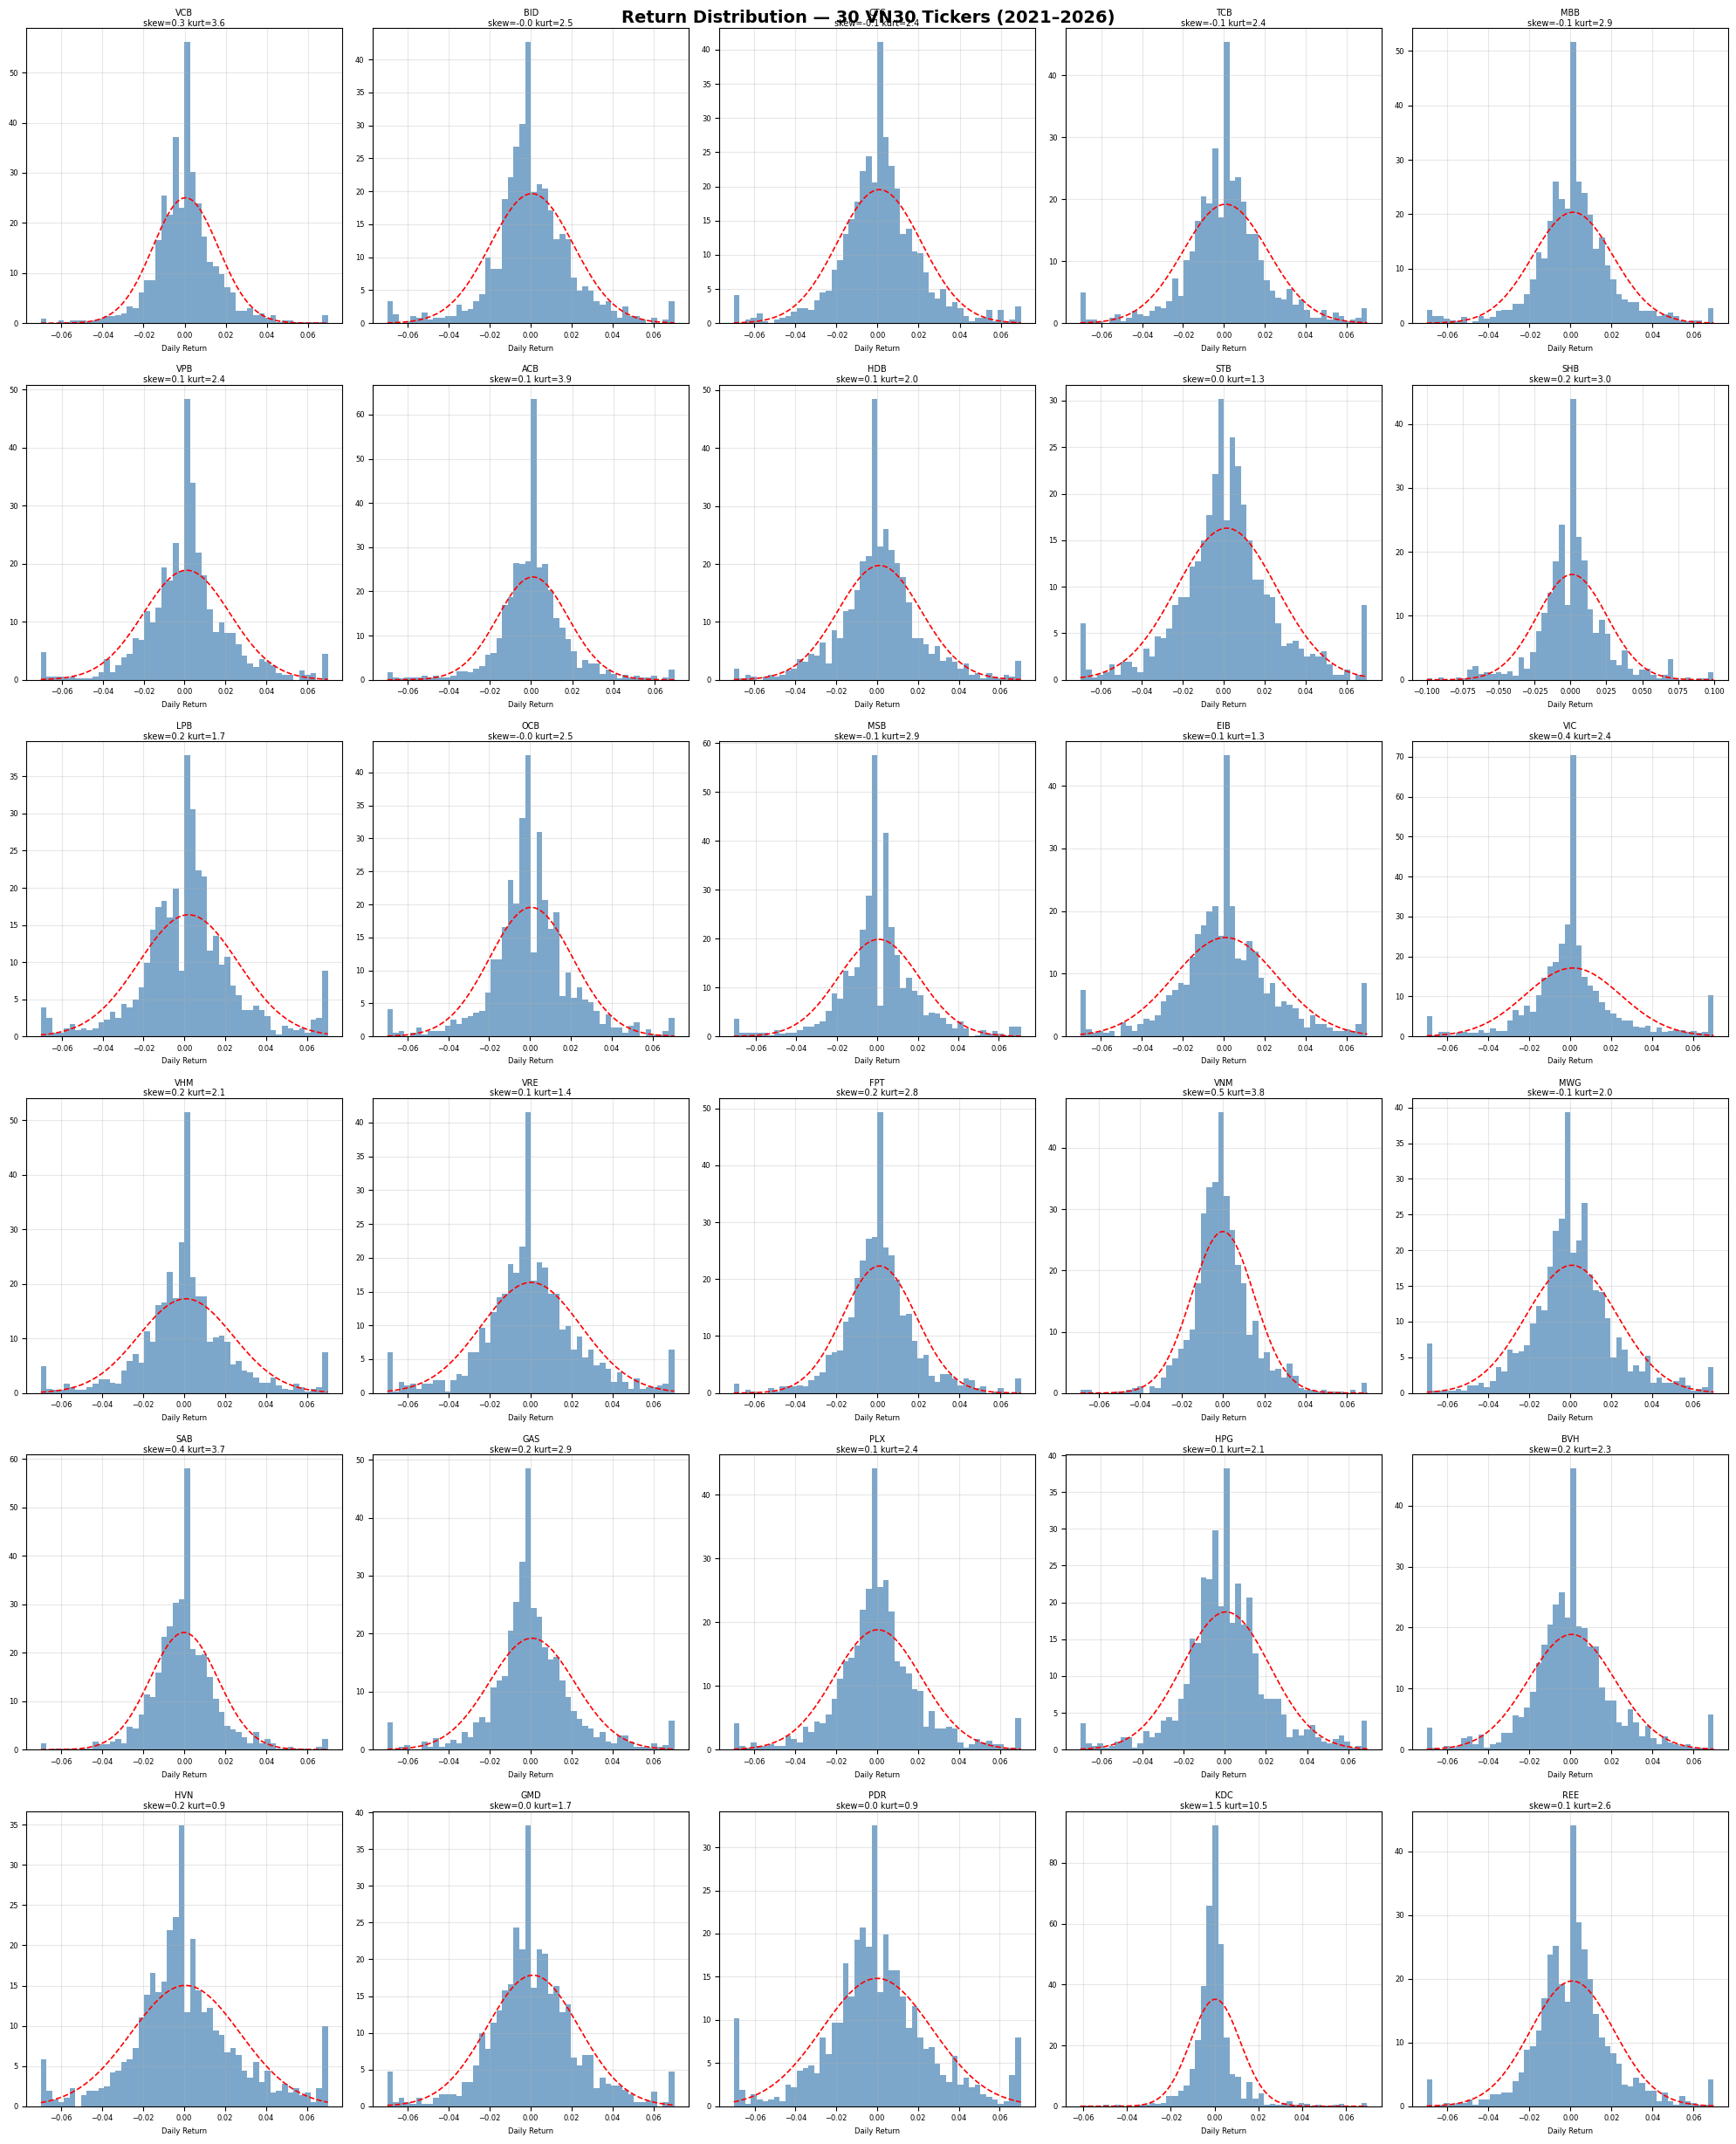

✅ Saved to reports/return_distributions_30tickers.png


In [5]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import sys
sys.path.append('../src')
from features import build_returns_matrix
from data_loader import VN30_TICKERS
import numpy as np
from scipy import stats

# Build returns matrix 30 mã
matrix = build_returns_matrix(VN30_TICKERS, '2021-01-01', '2026-04-10')

# Plot 30 histograms
fig = plt.figure(figsize=(20, 25))
fig.suptitle('Return Distribution — 30 VN30 Tickers (2021–2026)',
             fontsize=14, fontweight='bold', y=0.98)

for i, ticker in enumerate(VN30_TICKERS):
    ax = fig.add_subplot(6, 5, i + 1)
    ret = matrix[ticker].dropna()

    # Histogram
    ax.hist(ret, bins=50, color='steelblue', alpha=0.7, density=True)

    # Normal distribution overlay
    mu, sigma = ret.mean(), ret.std()
    x = np.linspace(ret.min(), ret.max(), 100)
    ax.plot(x, stats.norm.pdf(x, mu, sigma),
            color='red', linewidth=1.2, linestyle='--')

    # Skewness và kurtosis
    skew = ret.skew()
    kurt = ret.kurtosis()

    ax.set_title(f'{ticker}\nskew={skew:.1f} kurt={kurt:.1f}',
                 fontsize=7, pad=2)
    ax.set_xlabel('Daily Return', fontsize=6)
    ax.tick_params(labelsize=6)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/return_distributions_30tickers.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved to reports/return_distributions_30tickers.png")